In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from quspin.operators import hamiltonian
from DSF import *

In [3]:
N = 9
beta = [1/1]
w = np.linspace(0.0, 5.0, 500)
T = np.linspace(0, 10, 101)
# k_d = 120
# N_samples = 5

basis, r = build_basis(N, "1/2")
H = H_heisenburg(N, 0, basis, obc=True)
[E0] = H.eigsh(k=1, which="SA", maxiter=1e4, return_eigenvectors=False)
# psi_0 = psi_0.flatten()
# print(E0)

S1_list = []
S2_list = []
# momentum space at k = Q
# Q = np.pi
# for i in range(N):
#     S1_list.append([1/(N)**0.5 * np.exp(1j* Q*r[i]), i])
#     # S2_list.append([1/(N)**0.5 * np.exp(-1j* Q*r[i]), i])
#     S2_list.append([0, i])
# S2_list[4][0] = 1/(N)**0.5 * np.exp(-1j* Q*r[4])
Si = 4
for i in range(N):
    S1_list.append([0, i])
    S2_list.append([0, i])
S1_list[Si][0] = 1
S2_list[Si][0] = 1


Sz1 = hamiltonian([["z", S1_list]], [], basis=basis, dtype=np.complex128, check_herm = False)
Sz2 = hamiltonian([["z", S2_list]], [], basis=basis, dtype=np.complex128, check_herm = False)

# Szz, Z = dsf_lanczos(Sz1, Sz2, H, E0, k_d, N_samples, w, beta=beta)
# Szz_T0_L = dsf_lanczos_T0(Sz1, Sz2, H, E0, k_d, N_samples, w)
# Szz, Z = dsf_lanczos_src([Sz1], [Sz2], H, E0, psi_0, k_d, N_samples, w, beta=[10/1])

# E_0, V_0, Szz_full, Z_full, Szz_full_T0, M = dsf_exact(Sz1, Sz2, H, w, beta)
E_0, V_0, Szz_full, Z_full, Szz_full_T0, M = dsf_xt_exact(Sz1, Sz2, H, T, beta)

Hilbert space size: 512.

Hermiticity check passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
E0 = -3.7363217063793135
Eigenenergy: [0.00000000e+00 3.99680289e-15 4.53052425e-01 4.53052425e-01
 7.30540722e-01 7.30540722e-01 7.30540722e-01 7.30540722e-01
 8.74941872e-01 8.74941872e-01 1.13239260e+00 1.13239260e+00
 1.13239260e+00 1.13239260e+00 1.21168918e+00 1.21168918e+00
 1.40128724e+00 1.40128724e+00 1.42834562e+00 1.42834562e+00
 1.45394106e+00 1.45394106e+00 1.45394106e+00 1.45394106e+00
 1.54900951e+00 1.54900951e+00 1.54900951e+00 1.54900951e+00
 1.66105246e+00 1.66105246e+00 1.66105246e+00 1.66105246e+00
 1.71343252e+00 1.71343252e+00 1.74816778e+00 1.74816778e+00
 1.86395983e+00 1.86395983e+00 1.86395983e+00 1.86395983e+00
 1.90464324e+00 1.90464324e+00 1.90464324e+00 1.90464324e+00
 1.97091715e+00 1.97091715e+00 2.03307799e+00 2.03307799e+00
 2.06541913e+00 2.06541913e+00 2.06541913e+00 2.06541913e+00
 2.06541913e+00 2.06541913e+00 2.06681523e+00

In [10]:
for i in range(3):
    print(f"beta={beta[i]}, Mz={M[i]/Z_full[i]}")


beta=0.1, Mz=(-0.026223778645856274+0j)
beta=0.01, Mz=(-0.0025124786439358056+0j)
beta=0.001, Mz=(-0.0002501249791148266+0j)


# real space plot

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


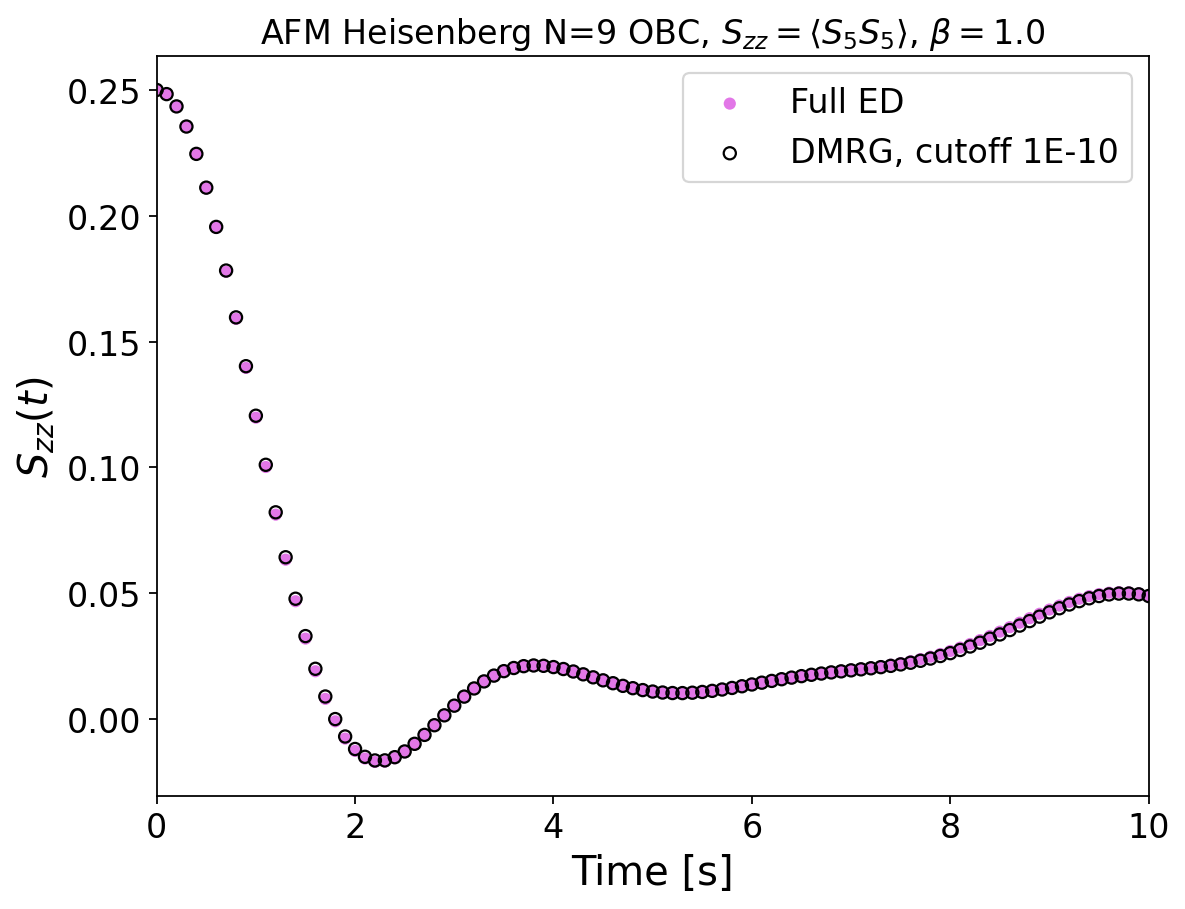

In [4]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

ax.scatter(T, Szz_full.flatten()/Z_full, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")
# ax.scatter(T, Szz_full_T0.flatten(), 
#     s=30, marker="o", c="#CC0FD690", edgecolors='none',
#     label="Full ED, T=0")

# dmrg = pd.read_csv("./Heisenberg_data/S_N9_k1.00_T5_dt0.05_beta0.01_zz.csv")
# ax.scatter(w, dmrg.RS/100,
#     marker="h", c="#29CCE9FF", edgecolors="#FF1418C8", linewidths=0.8, s=36, 
#     label=f"scaled DMRG, T=5"
#     )
dmrg = pd.read_csv("./Heisenberg_data/Chi_N9_S5S5_Tau10_dt0.05_beta1.00_zz_err-10.csv")
ax.scatter(dmrg.t, dmrg.RS,
    s=30, marker="o", c="none", edgecolors='k', 
    label=f"DMRG, cutoff 1E-10"
    )

# dmrg = pd.read_csv(f"./Heisenberg_data/Chi_N9_S{Si+1}S{Si+1}_Tau5_dt0.05_betaInf_zz_ran_phy.csv")
# ax.scatter(dmrg.t, dmrg.RS,
#     s=30, marker="s", c="none", edgecolors='k', 
#     label=f"DMRG, random state"
#     )
# dmrg = pd.read_csv(f"./Heisenberg_data/Chi_N9_S{Si+1}S{Si+1}_Tau5_dt0.05_betaInf_zz_ran_phy_sim.csv")
# ax.scatter(dmrg.t, dmrg.RS,
#     s=30, marker="v", c="none", edgecolors='k', 
#     label=f"DMRG, random state, sim"
#     )
# dmrg = pd.read_csv(f"./Heisenberg_data/Chi_N9_S{Si+1}S{Si+1}_Tau5_dt0.05_betaInf_zz_QNz_phy.csv")
# ax.scatter(dmrg.t, dmrg.RS,
#     s=30, marker="o", c="none", edgecolors='k', 
#     label=f"DMRG, QN conserved(AFM)"
#     )
# dmrg = pd.read_csv(f"./Heisenberg_data/Chi_N9_S{Si+1}S{Si+1}_Tau5_dt0.05_betaInf_zz_QNz_phy_sim.csv")
# ax.scatter(dmrg.t, dmrg.RS,
#     s=30, marker="^", c="none", edgecolors='k', 
#     label=f"DMRG, QN conserved, sim"
#     )

# dmrg = pd.read_csv(f"./Heisenberg_data/Chi_N9_S{Si+1}S{Si+1}_Tau5_dt0.05_betaInf_zz_QNz_phy_trosim.csv")
# ax.scatter(dmrg.t, dmrg.RS,
#     s=30, marker=".", c="none", edgecolors='k', 
#     label=f"TEBD, QN conserved, sim"
#     )
# dmrg = pd.read_csv(f"./Heisenberg_data/Chi_N9_S{Si+1}S{Si+1}_Tau5_dt0.05_betaInf_zz_ran_phy_trosim.csv")
# ax.scatter(dmrg.t, dmrg.RS,
#     s=30, marker="^", c="none", edgecolors='k', 
#     label=f"TEBD, random state, sim"
#     )

ax.legend(fontsize=15)
ax.set_xlabel("Time [s]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(t)$", fontsize=18)
ax.set_xlim(0, 10)
# ax.set_ylim(-0.2, 2.5)
# ax.set_ylim(-0.01, 0.1)
# ax.set_ylim(-0.01, 0.3)
# ax.set_ylim(-0.001, 0.015)
ax.tick_params(axis='both', labelsize=15)

# {beta[0]}
ax.set_title(f"AFM Heisenberg N={N} OBC, $S_{{zz}} = \\langle S_{Si+1} S_{Si+1}\\rangle$, $\\beta={beta[0]}$", fontsize=15)
plt.show()

# Momentum space

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


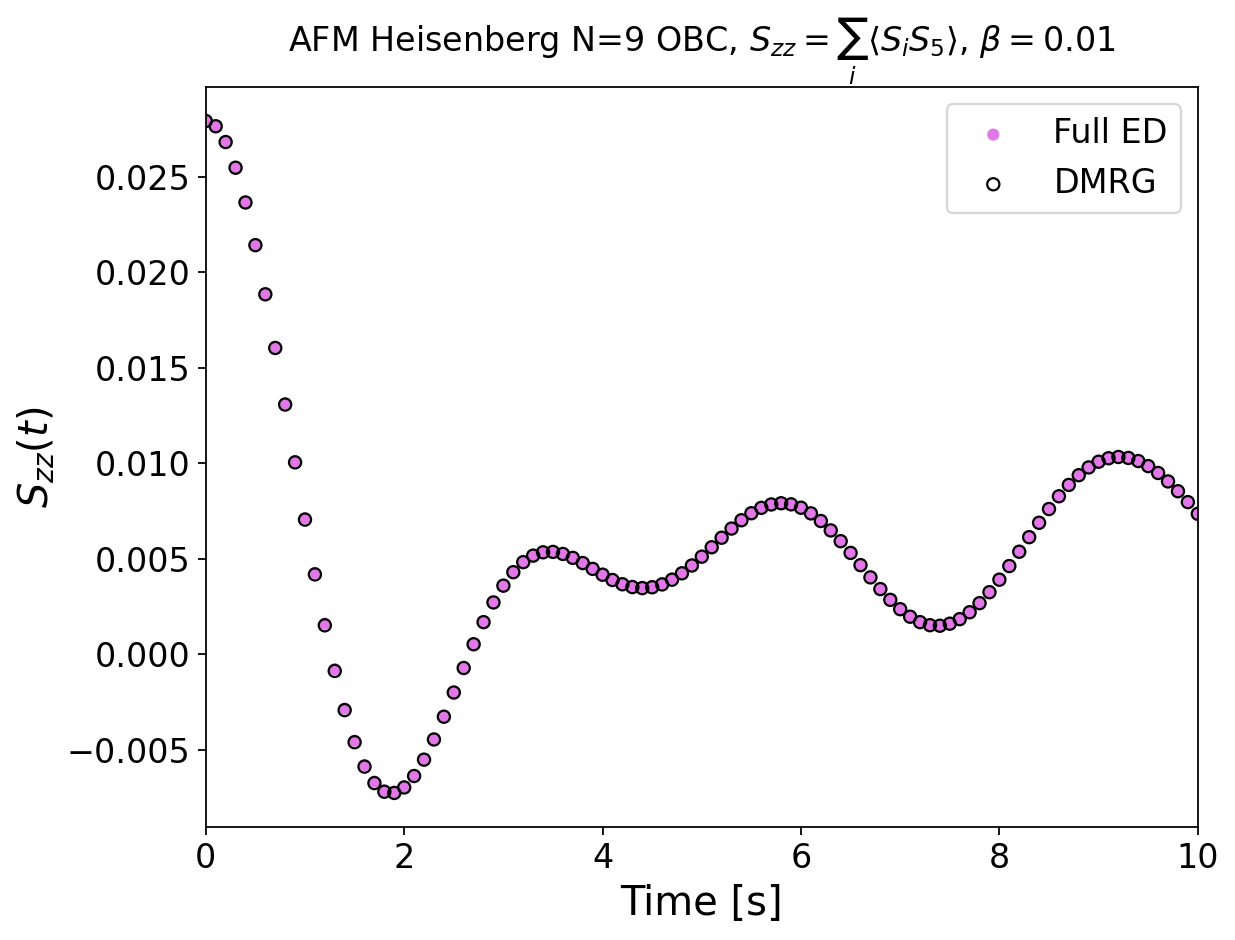

In [16]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=160)

ax.scatter(T, Szz_full.flatten()/Z_full, 
    s=30, marker="o", c="#CC0FD690", edgecolors='none',
    label="Full ED")
dmrg = pd.read_csv("./Heisenberg_data/Chi_N9_k1.00_Tau10_dt0.05_beta0.01_zz.csv")
ax.scatter(dmrg.t, dmrg.RS/9,
    s=30, marker="o", c="none", edgecolors='k', 
    label=f"DMRG"
    )

ax.legend(fontsize=15)
ax.set_xlabel("Time [s]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(t)$", fontsize=18)
ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=15)

# {beta[0]}
ax.set_title(f"AFM Heisenberg N={N} OBC, $S_{{zz}} = \\sum_i \\langle S_i S_5\\rangle$, $\\beta={beta[0]}$", fontsize=15)
plt.show()

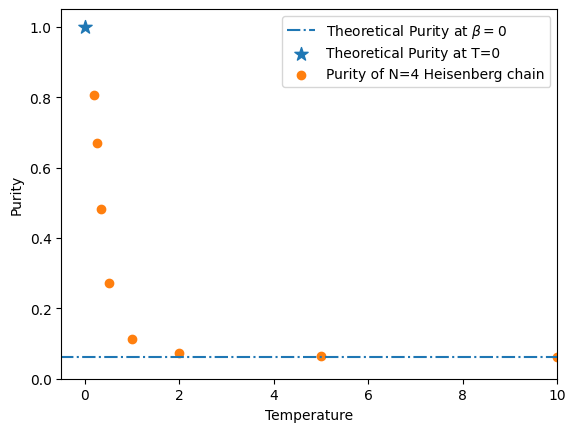

In [16]:
data = pd.read_csv("./Heisenberg_data/N4_purity.csv")
T = 1/data.beta 

fig, ax = plt.subplots()

ax.plot([-1, 101], [1/16, 1/16], label="Theoretical Purity at $\\beta=0$", ls="-.")
ax.scatter(0.001, 1, marker="*", s=100, label="Theoretical Purity at T=0")
ax.scatter(T, data.rho2, marker="o", label="Purity of N=4 Heisenberg chain")

ax.legend()
ax.set_xlim(-0.5, 10)
ax.set_ylim(0, 1.05)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel("Temperature")
ax.set_ylabel("Purity")
plt.show()

# FF space plot

In [17]:
data = pd.read_csv("./Heisenberg_data/Chi_N9_k1.00_Tau10_dt0.05_beta0.01_zz.csv")
chi = list(data.RS)
Time = list(data.t)
dt = 0.1
S = []
for idx, omega in enumerate(w):
    int_sum = 0
    for i in range(len(Time)):
        int_sum += np.exp(1j * omega * Time[i]) * chi[i]
    S.append(int_sum*dt)

/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/amos1/miniconda3/envs/quspin/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


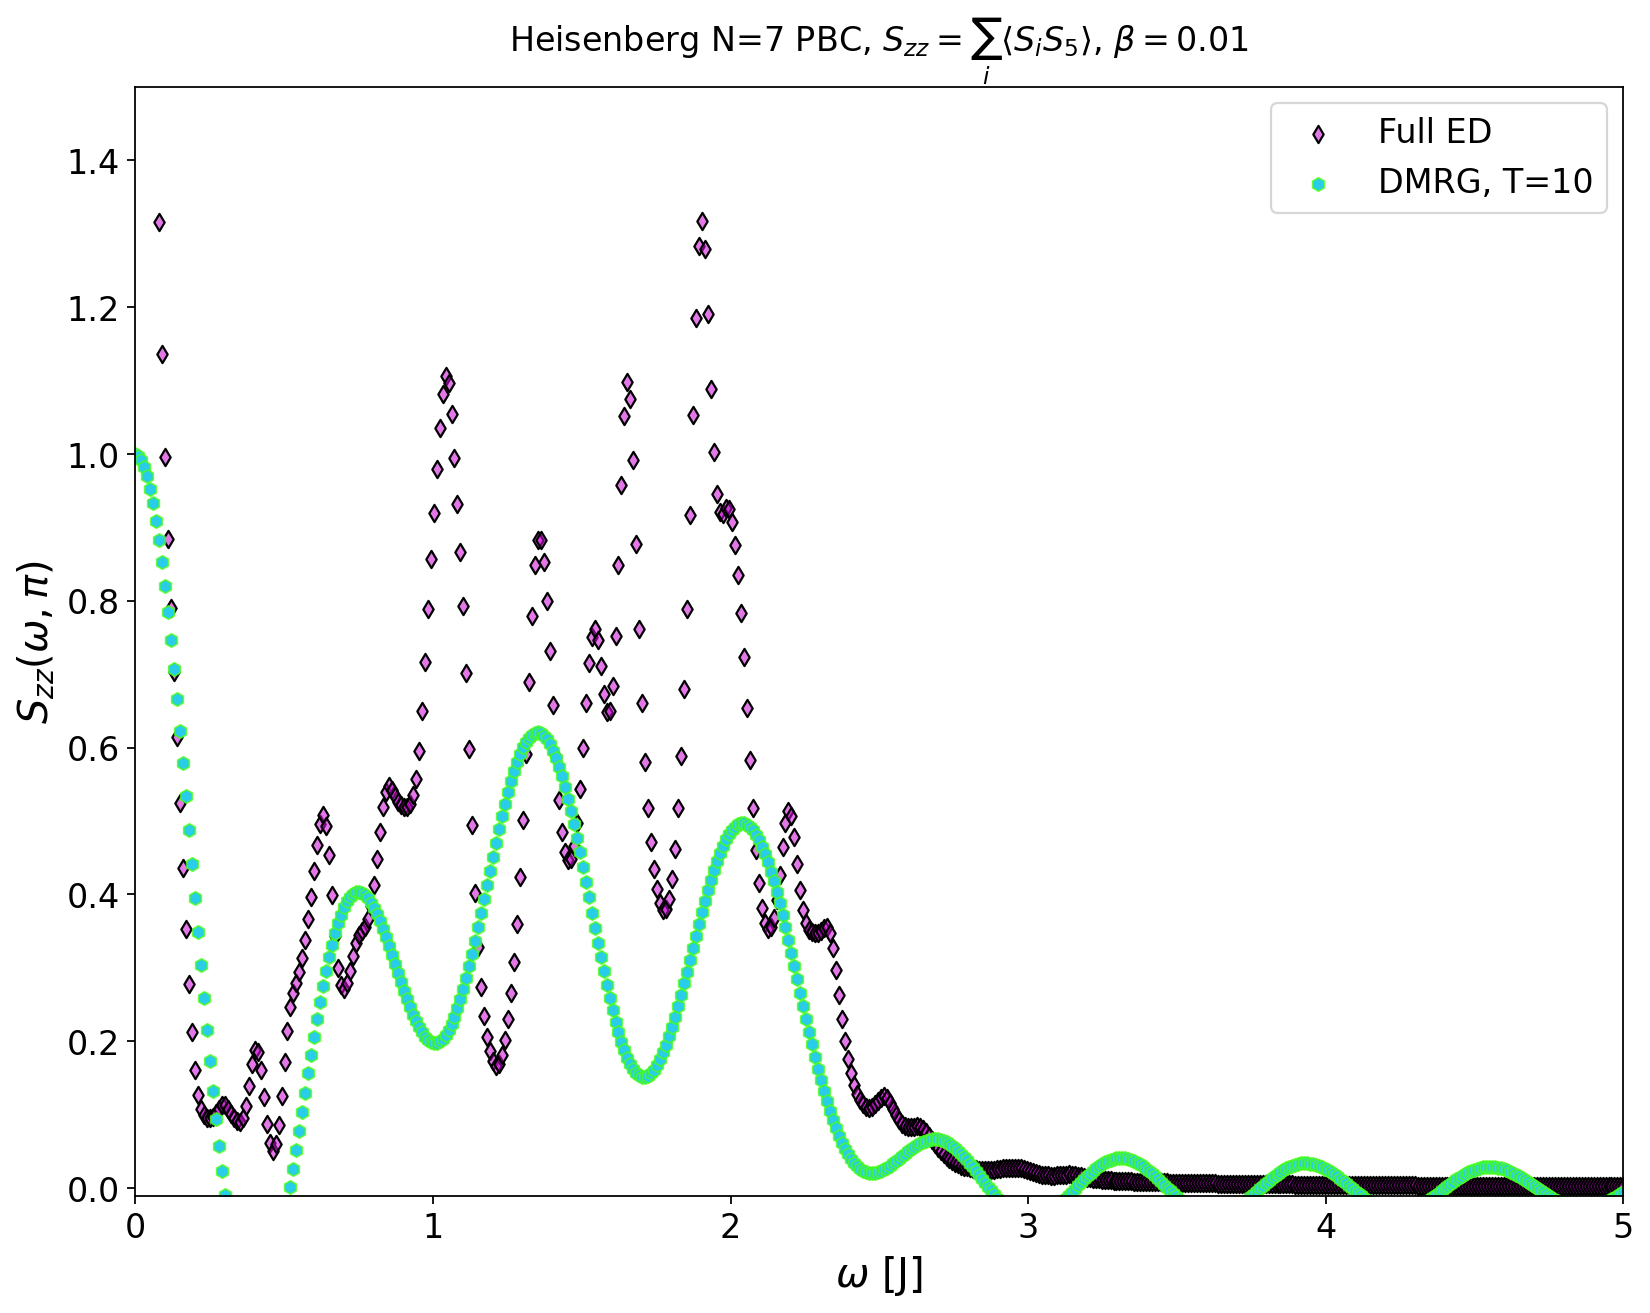

In [24]:
fig, ax = plt.subplots(figsize=(12, 9), dpi=160)

# for i in range(N_samples):
#     if i == 0: label = "Lanczos ED samples"
#     else: label = None
#     ax.scatter(w, Szz[i]/Z[i],
#         s=5, alpha=0.1, c="#F03333", label=label)
    
# ax.scatter(w, a3, 
#     s=20, marker="D", c="#F192E6DE", edgecolors='#F03333',
#     label="Mean Lanczos samples")

ax.scatter(w, Szz_full.flatten()/Z_full*81, 
    s=30, marker="d", c="#CC0FD690", edgecolors='k',
    label="Full ED")

ax.scatter(w, S,
    marker="h", c="#29CCE9FF", edgecolors="#47FF14C6", linewidths=0.8, s=36, 
    label=f"DMRG, T=10"
    )

ax.legend(fontsize=15)
ax.set_xlabel("$\\omega$ [J]", fontsize=18)
ax.set_ylabel("$S_{{zz}}(\\omega, \\pi)$", fontsize=18)
ax.set_xlim(0, 5)
# ax.set_ylim(-0.2, 2.5)
ax.set_ylim(-0.01, 1.5)
# ax.set_ylim(-0.001, 0.015)
ax.tick_params(axis='both', labelsize=15)

ax.set_title(f"Heisenberg N={N} PBC, $S_{{zz}} = \\sum_i \\langle S_i S_5\\rangle$, $\\beta={beta[0]}$", fontsize=15)
plt.show()